# Give a title here
This notebook intends to provide a Quantitative Validation of single object Masks. 
For this,  we align GRIDGENE-generated cell masks with IMC reference images. To note, cell based approaches are more relevant in CosMx data. However, IF data does not provide enough markers to function as reference. 

In [1]:
# %load_ext autoreload

# import os 
# import sys
# import time
# import logging
# import re
# from tqdm import tqdm
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image
# import json

# from natsort import natsorted
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import matplotlib.cm as cm
# from PIL import Image, ImageDraw
# import json
# import math
# import matplotlib.patches as mpatches
# import matplotlib.patches as patches
# from skimage.measure import label



# import os
# from glob import glob
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import ndimage
# from skimage import morphology
# import tifffile

# from src.file_specs import FileSpecifics
# import src.ImageParser as IP
# from pathlib import Path
# import tifffile
# import numpy as np
# from scipy import ndimage
# from skimage import morphology
# import numpy as np
# import tifffile
# import matplotlib.pyplot as plt

# import os
# from pathlib import Path
# import pandas as pd
# sys.path.append(os.path.dirname(os.getcwd()))
# from gridgene import get_arrays as ga
# from gridgene import contours, get_masks 
# from gridgene.mask_properties import MaskAnalysisPipeline, MaskDefinition, MorphologyExtractor
# from gridgene.get_masks import MultiClassObjectAnalysis
# import sys
# sys.path.append('/home/martinha/PycharmProjects/phd/Preprocess_IMC')
# from helper_plot import plot_TRGC_TRDC_points_polygons, plot_TRGC_TRDC_points_contours, plot_TRGC_TRDC_points_mask



%load_ext autoreload
%autoreload 2

import os 
import sys
import time
import logging
import re
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from natsort import natsorted
import json

import cv2
import numpy as np
from PIL import Image
import tifffile as tiff
import copy 
import random
from natsort import natsorted
import sys
from pathlib import Path
import re
from shapely.geometry import Polygon

# Add GRIDGENE root to path
# You need to go up 2 levels
gridgene_root = Path.cwd().parent.parent  # analyses/quantification -> analyses -> GRIDGENE
sys.path.insert(0, str(gridgene_root))

print(f"Added to path: {gridgene_root}")
print(f"gridgene package location: {gridgene_root / 'gridgene'}")
from gridgene import get_arrays as ga
from gridgene import contours 
from gridgene import get_masks
      
      

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile
import cv2
from tqdm import tqdm

# Add GRIDGENE to path
gridgene_root = Path.cwd().parent.parent
sys.path.insert(0, str(gridgene_root))

# Import GRIDGENE modules
from gridgene import get_arrays as ga
from gridgene import contours, get_masks

# Import quantification modules
sys.path.append(str(Path.cwd().parent / 'scripts'))
from scripts.preprocessing import preprocess_if_image, register_masks_to_image
from scripts.metrics import calculate_overlap_metrics, calculate_enrichment

print("✓ Imports successful")
print(f"Working directory: {Path.cwd()}")
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from matplotlib.patches import Patch
import tifffile
import os
from natsort import natsorted
import copy
      
from scipy import ndimage
from skimage import morphology
import numpy as np
import matplotlib.pyplot as plt

from skimage import morphology
import cv2
      
import sys
sys.path.append('/home/martinha/PycharmProjects/phd/Preprocess_IMC')

import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology
import tifffile

from src.file_specs import FileSpecifics
import src.ImageParser as IP
from pathlib import Path
import tifffile
import numpy as np
from scipy import ndimage
from skimage import morphology
import numpy as np
import tifffile
import matplotlib.pyplot as plt

import os
from pathlib import Path
import pandas as pd


Added to path: /home/martinha/PycharmProjects/phd/GRIDGENE
gridgene package location: /home/martinha/PycharmProjects/phd/GRIDGENE/gridgene
✓ Imports successful
Working directory: /home/martinha/PycharmProjects/phd/GRIDGENE/analyses/quantitative_validation


In [2]:
# define the logger :  can be None, and is set to INFO
# Custom logger setup
logger = logging.getLogger('contour_logger')
handler = logging.StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)
logger.setLevel(logging.INFO)

# update this etxt
We will now do the same quantitative analysis but this time with Xenium data. Importantly we only have 3 cores matching Imaging Mass Cytometry (IMC) experiments. We will 
    - (1) Run gridgene pipeline on Xenium;
    - (2) Fetch IMC correspondending images, preprocessing and creation of masks. 
    - (3) Analyse quantitatively the overlay between gridgene and IMC masks. 
    - (4) Fetch cell segmentation (done with Baysor - https://doi.org/10.1038/s41587-021-01044-w) and phenotyping.

Importantly, the overlay between both images would depend on the parametes used both in gridgen and the preprocessing of IF, meaning, depending on the degree of details, mas can become more smooth or more fine grained.

Define Paths

### 1. Imaging Mass cytometry images - IMC
Lets open the IMC images to check how they are. IMC images have 40+ markers and were preprocessed using PENGUIN.

In [3]:
# ============================================================================
# XENIUM + IMC CONFIGURATION
# ============================================================================

# Base paths
xenium_base_path = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium_data/HLA/GD_TMA1_S3/fov_filtered'
imc_base_path = "/home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/case_studies/PENGUINcompositesIMC"
baysor_base_path_xenium = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium/HLA_analysis/cell_segmentation/cells_prior07'

# Shared files (same for all ROIs)
phenotype_h5ad_path = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium/HLA_analysis/cell_prior07_v20_03.h5ad'
selection_coords_path = '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/xenium_data/HLA/GD_TMA1_S3/coordinates_HLA1.csv'

# ROI to Selection mapping
roi_to_selection = {
    'ROI001': 'Selection8',
    'ROI002': 'Selection32',
    'ROI003': 'Selection13'
}

# Build the ROI data dictionary
roi_data = {
    'ROI001': {
        'xenium_path': os.path.join(xenium_base_path, 'TMA1_Selection8_filtered.csv'),
        'imc_path': os.path.join(imc_base_path, 'ROI001_ROI_001.ome.tiff'),
        'baysor_folder': os.path.join(baysor_base_path_xenium, 'TMA1_Selection8'),
        'baysor_json': os.path.join(baysor_base_path_xenium, 'TMA1_Selection8', 'segmentation_polygons.json'),
        'selection_name': 'Selection8'
    },
    'ROI002': {
        'xenium_path': os.path.join(xenium_base_path, 'TMA1_Selection32_filtered.csv'),
        'imc_path': os.path.join(imc_base_path, 'ROI002_ROI_002.ome.tiff'),
        'baysor_folder': os.path.join(baysor_base_path_xenium, 'TMA1_Selection32'),
        'baysor_json': os.path.join(baysor_base_path_xenium, 'TMA1_Selection32', 'segmentation_polygons.json'),
        'selection_name': 'Selection32'
    },
    'ROI003': {
        'xenium_path': os.path.join(xenium_base_path, 'TMA1_Selection13_filtered.csv'),
        'imc_path': os.path.join(imc_base_path, 'ROI003_ROI_003.ome.tiff'),
        'baysor_folder': os.path.join(baysor_base_path_xenium, 'TMA1_Selection13'),
        'baysor_json': os.path.join(baysor_base_path_xenium, 'TMA1_Selection13', 'segmentation_polygons.json'),
        'selection_name': 'Selection13'
    }
}

In [7]:
# Load IMC images
# ============================================================================
# Get IMC image files from roi_data dictionary
imc_files = [paths['imc_path'] for roi_name, paths in roi_data.items() 
             if paths['imc_path'] and os.path.exists(paths['imc_path'])]

# Load channel names from first image
specs = FileSpecifics(imc_files[0], multitiff=True)
imc_channel_names = specs.channel_names
print(f"\n {len(imc_channel_names)} channels detected")

# Load all images
imc_images = list(map(IP.parse_image_pages, imc_files))
print(f"Loaded {len(imc_images)} IMC images")

print(f"Sample channels: {imc_channel_names}")
# Add images to roi_data dictionary
for idx, (roi_name, paths) in enumerate(sorted(roi_data.items())):
    if idx < len(imc_images):
        roi_data[roi_name]['imc_image'] = imc_images[idx]
        roi_data[roi_name]['channel_names'] = imc_channel_names

print("✓ Added IMC images to roi_data")


 50 channels detected
Loaded 3 IMC images
Sample channels: ['80Ar(ArAr80Di)', 'TGFb(Y89Di)', 'IFNy(In115Di)', '127I(I127Di)', '131Xe(Xe131Di)', '134Xe(Xe134Di)', '138Ba(Ba138Di)', 'HLA-DR(Pr141Di)', 'CD20(Nd142Di)', 'CD68(Nd143Di)', 'CD11b(Nd144Di)', 'CD4(Nd145Di)', 'CD8a(Nd146Di)', 'CD31(Sm147Di)', 'TCRgd(Nd148Di)', 'CD45(Sm149Di)', 'GranzymeB(Nd150Di)', 'CD57(Eu151Di)', 'Ki-67(Sm152Di)', 'CD3(Eu153Di)', 'IgG1(Sm154Di)', 'CD138(Gd155Di)', 'PDL1(Gd156Di)', 'CD39(Gd157Di)', 'VISTA(Gd158Di)', 'FOXP3(Tb159Di)', 'PD-1(Gd160Di)', 'ICOS(Dy161Di)', 'IDO(Dy162Di)', 'CD14(Dy163Di)', 'CD204(Dy164Di)', 'CD45RO(Ho165Di)', 'D2-40(Er166Di)', 'CD56(Er167Di)', 'CD103(Er168Di)', 'CD38(Tm169Di)', 'Tbet(Er170Di)', 'CD15(Yb171Di)', 'C_caspase3(Yb172Di)', 'CD163(Yb173Di)', 'CD7(Yb174Di)', 'CD27(Lu175Di)', 'CD11c(Yb176Di)', '190BCKG(BCKG190Di)', 'DNA1(Ir191Di)', 'DNA2(Ir193Di)', 'Vimentin(Pt194Di)', 'Bcatenin(Pt196Di)', 'Keratin(Pt198Di)', 'Histone(Bi209Di)']
✓ Added IMC images to roi_data


Because we have so many markers, we will choose the ones to create a mask of epithelial, stroma and immune compartments. 

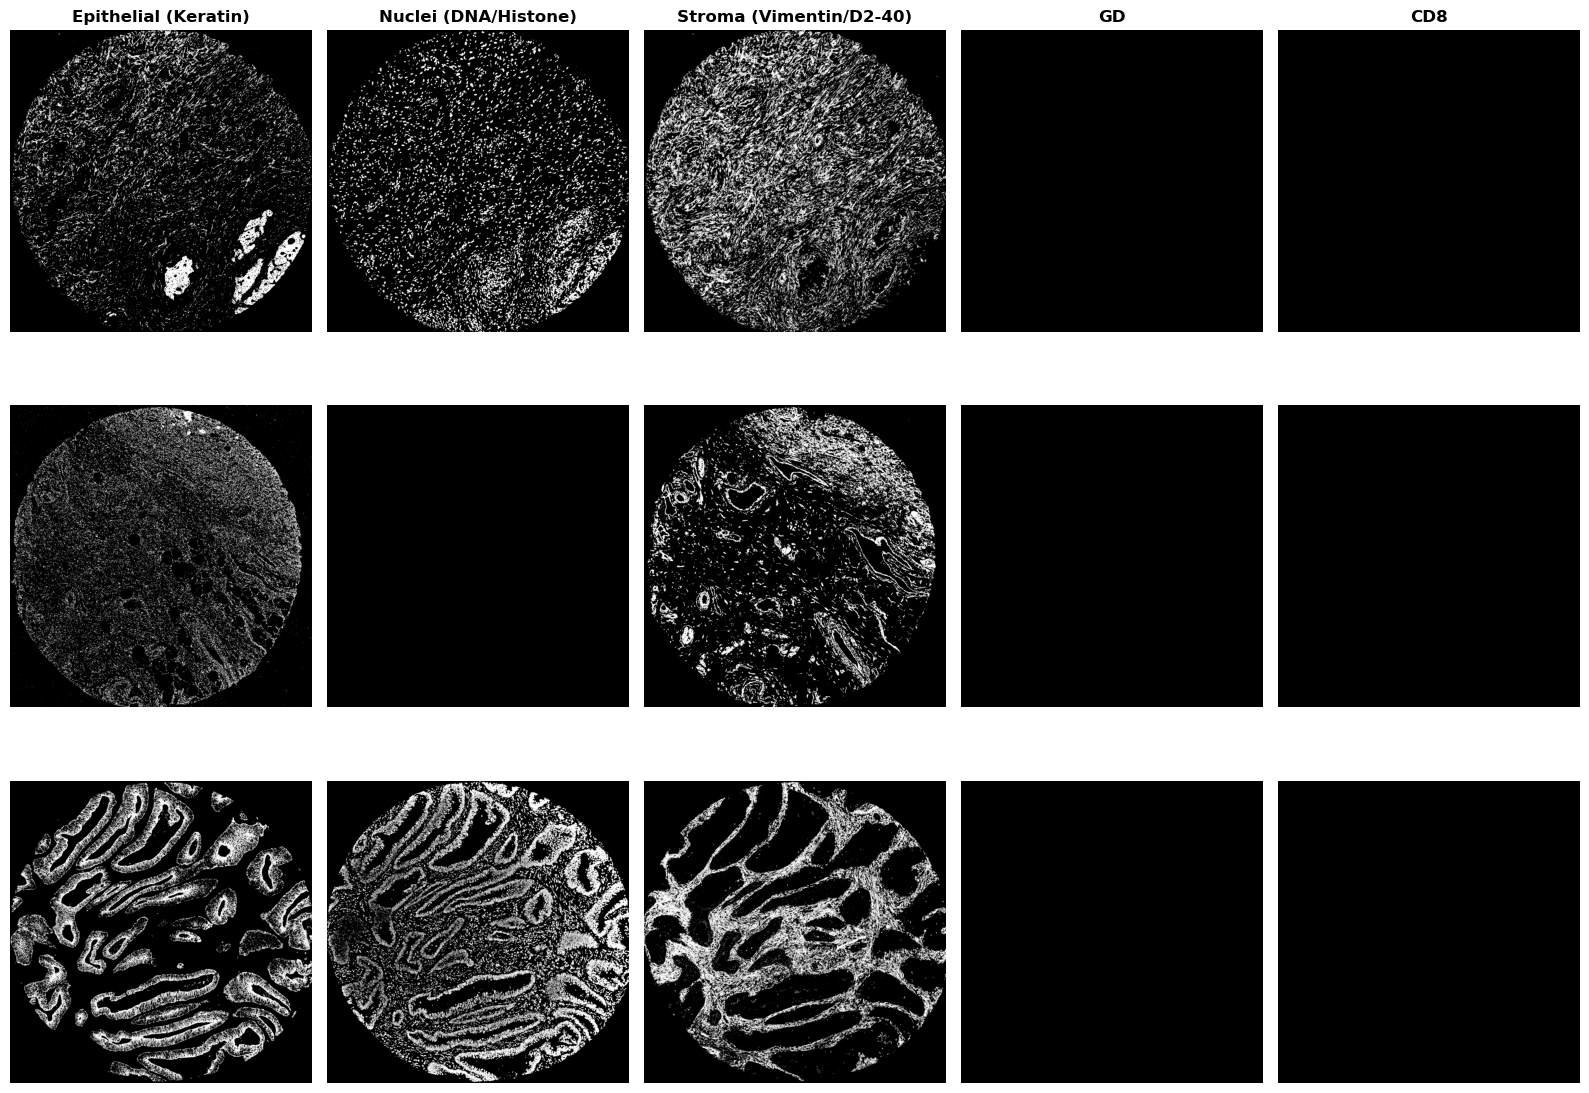

In [29]:
# ============================================================================
# Extract channels for each FOV
# ============================================================================
def get_channel_idx(channel_names, marker_name):
    """Helper to find channel index by marker name"""
    for i, ch in enumerate(channel_names):
        if marker_name in ch:
            return i
    return None

def get_sum_channels(image, channel_names, interest_channels):
    """Sum multiple channels together"""
    result = np.zeros(image.shape[:2], dtype=np.float32)
    for interest_ch in interest_channels:
        interest_ch_idx = get_channel_idx(channel_names, interest_ch)
        if interest_ch_idx is not None:
            result += image[:, :, interest_ch_idx]
    return result

# Extract channels for each FOV
for fov_name in sorted(roi_data.keys()):
    if 'imc_image' not in roi_data[fov_name]:
        continue
    
    imc_image = roi_data[fov_name]['imc_image']
    channel_names = roi_data[fov_name]['channel_names']
    
    epithelial = get_sum_channels(imc_image, channel_names, interest_channels=['Keratin'])
    nuclei = get_sum_channels(imc_image, channel_names, interest_channels=['DNA1', 'DNA2', ])
    stroma = get_sum_channels(imc_image, channel_names, interest_channels=['Vimentin', 'D2-40'])
    gd = get_sum_channels(imc_image, channel_names, interest_channels=['TCRgd(Nd148Di)'])
    
    # check this definitions with the CellCytoLego
    cd8 = get_sum_channels(imc_image, channel_names, interest_channels=['CD8a'])
    fibroblasts = get_sum_channels(imc_image, channel_names, interest_channels=['Vimentin'])
    
    # Store extracted channels
    roi_data[fov_name]['channels'] = {
        'epithelial': epithelial,
        'nuclei': nuclei,
        'stroma': stroma,
        'gd': gd,
        'cd8':cd8,
    }
    
    
# ============================================================================
# Plot: Each FOV in a row with 4 channel masks
# ============================================================================
fov_names = sorted(roi_data.keys())
n_fovs = len(fov_names)


channel_names = ['epithelial', 'nuclei', 'stroma', 'gd', 'cd8']
channel_labels = ['Epithelial (Keratin)', 'Nuclei (DNA/Histone)', 'Stroma (Vimentin/D2-40)', 'GD', 'CD8']


fig, axes = plt.subplots(n_fovs, len(channel_names), figsize=(16, 4*n_fovs))

# Make sure axes is 2D
if n_fovs == 1:
    axes = axes.reshape(1, -1)

for row_idx, fov_name in enumerate(fov_names):
    for col_idx, (ch_name, ch_label) in enumerate(zip(channel_names, channel_labels)):
        ax = axes[row_idx, col_idx]
        
        # Get channel image
        channel_img = roi_data[fov_name]['channels'][ch_name]
        vmax = np.percentile(channel_img, 90)
        
        # Plot
        ax.imshow(channel_img, cmap='gray', vmin=0, vmax=vmax)
        
        # Add title to first row
        if row_idx == 0:
            ax.set_title(ch_label, fontsize=12, fontweight='bold')
        
        # Add FOV name to first column
        if col_idx == 0:
            ax.set_ylabel(fov_name, fontsize=12, fontweight='bold', rotation=0, 
                         ha='right', va='center', labelpad=20)
        
        ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Define Gridgene masks 

Define masks for γδ T cellls, CD8 T cells and fibroblasts? 


Processing ROI001...


2026-02-06 00:01:24,853 - contour_logger - INFO - Initialized GetContour
2026-02-06 00:01:24,918 - contour_logger - INFO - get_conv_sum took 0.0612 seconds
2026-02-06 00:01:24,954 - contour_logger - INFO - Number of contours after filtering no counts: 44
2026-02-06 00:01:24,954 - contour_logger - INFO - contours_from_sum took 0.0361 seconds
2026-02-06 00:01:25,034 - contour_logger - INFO - Excluding contour 0. gd count 1.00 ≤ ab count 2.00
2026-02-06 00:01:25,043 - contour_logger - INFO - Excluding contour 1. gd count 2.00 ≤ ab count 4.00
2026-02-06 00:01:25,136 - contour_logger - INFO - Excluding contour 12. gd count 6.00 ≤ ab count 7.00
2026-02-06 00:01:25,331 - contour_logger - INFO - Excluding contour 35. gd count 1.00 ≤ ab count 1.00
2026-02-06 00:01:25,397 - contour_logger - INFO - Contours remaining after gene comparison: 40
2026-02-06 00:01:25,406 - contour_logger - INFO - Excluding contour 1. Gene TRDC count  0.0 is below threshold 1
2026-02-06 00:01:25,428 - contour_logger - 

total contours found  33


2026-02-06 00:01:25,961 - contour_logger - INFO - Number of contours remaining: 20
2026-02-06 00:01:25,966 - contour_logger - INFO - Excluding contour 0. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:25,975 - contour_logger - INFO - Excluding contour 2. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:26,006 - contour_logger - INFO - Excluding contour 9. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:26,010 - contour_logger - INFO - Excluding contour 10. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:26,015 - contour_logger - INFO - Excluding contour 11. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:26,041 - contour_logger - INFO - Excluding contour 17. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:26,046 - contour_logger - INFO - Excluding contour 18. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:26,051 - contour_logger - INFO - Number of contours remaining: 13
2026-02-06 00:01:26,088 - contour_logge

total contours found  9


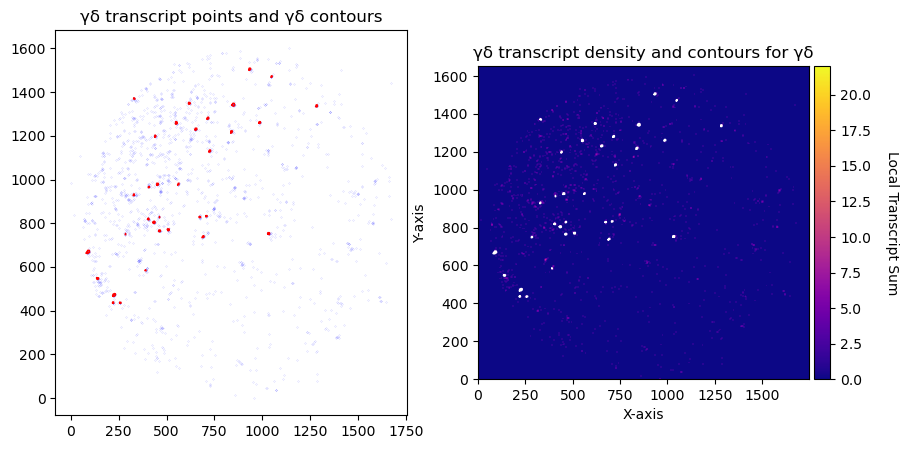

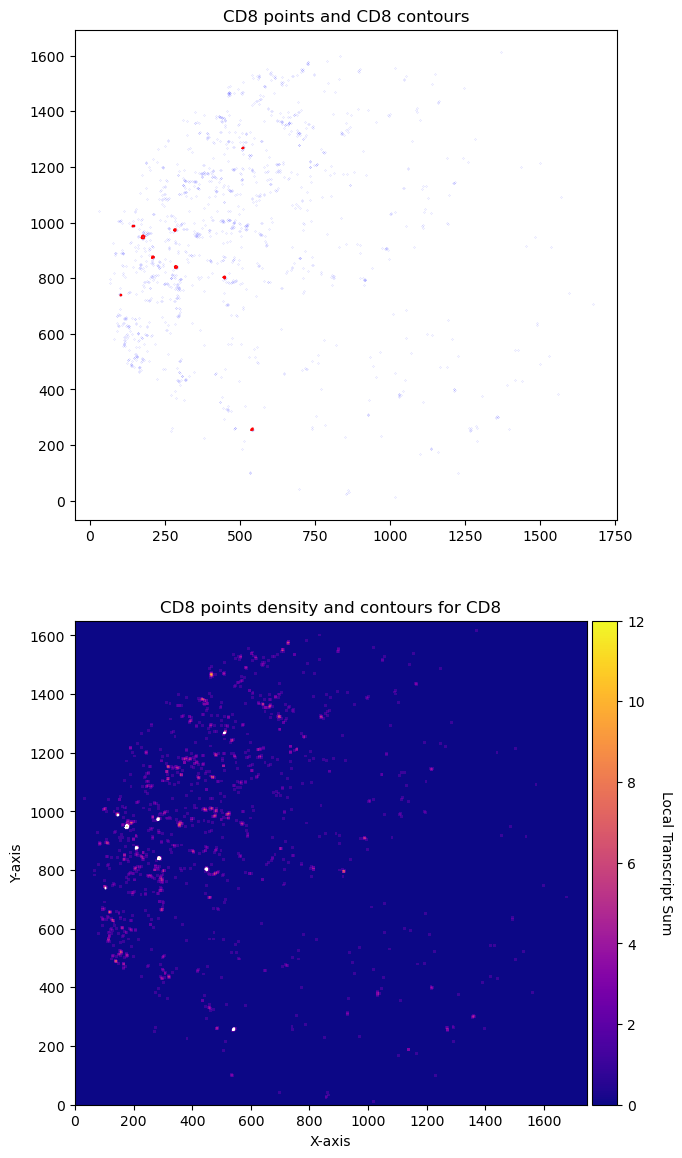

2026-02-06 00:01:27,287 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2026-02-06 00:01:27,288 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.
2026-02-06 00:01:27,289 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.


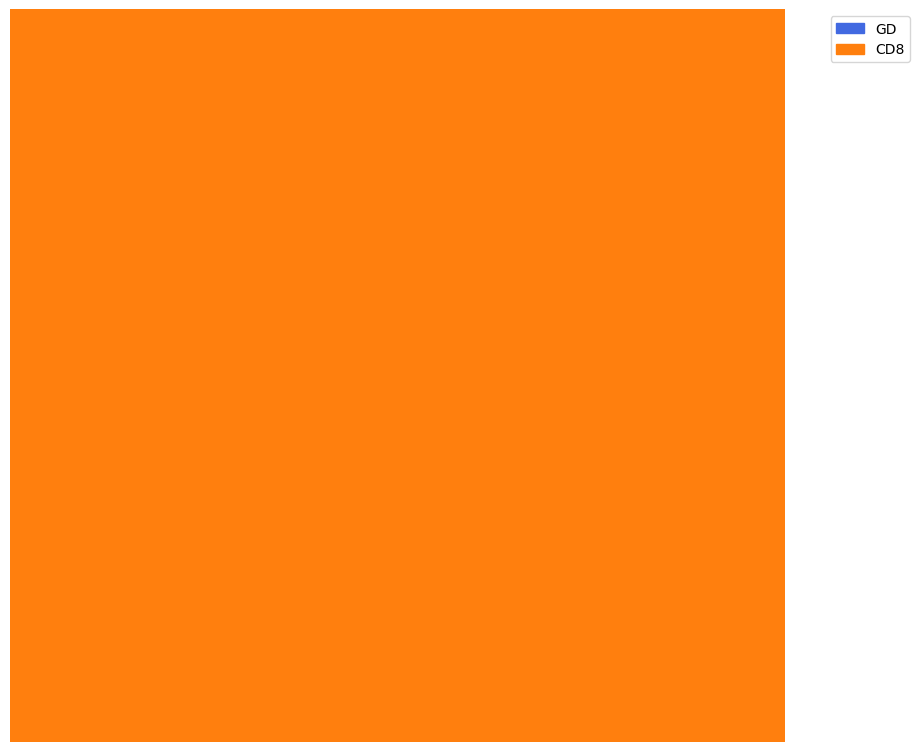

 Completed ROI001

Processing ROI002...


2026-02-06 00:01:29,340 - contour_logger - INFO - Initialized GetContour
2026-02-06 00:01:29,406 - contour_logger - INFO - get_conv_sum took 0.0650 seconds
2026-02-06 00:01:29,453 - contour_logger - INFO - Number of contours after filtering no counts: 8
2026-02-06 00:01:29,454 - contour_logger - INFO - contours_from_sum took 0.0477 seconds
2026-02-06 00:01:29,592 - contour_logger - INFO - Contours remaining after gene comparison: 8
2026-02-06 00:01:29,628 - contour_logger - INFO - Number of contours remaining: 8
2026-02-06 00:01:29,672 - contour_logger - INFO - Excluding contour 1. Gene TRGC1_2 count  0.0 is below threshold 1
2026-02-06 00:01:29,682 - contour_logger - INFO - Excluding contour 3. Gene TRGC1_2 count  0.0 is below threshold 1
2026-02-06 00:01:29,687 - contour_logger - INFO - Excluding contour 4. Gene TRGC1_2 count  0.0 is below threshold 1
2026-02-06 00:01:29,700 - contour_logger - INFO - Number of contours remaining: 5
2026-02-06 00:01:29,701 - contour_logger - INFO - In

total contours found  5


2026-02-06 00:01:29,956 - contour_logger - INFO - Number of contours remaining: 23
2026-02-06 00:01:29,966 - contour_logger - INFO - Excluding contour 1. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:29,971 - contour_logger - INFO - Excluding contour 2. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:29,985 - contour_logger - INFO - Excluding contour 5. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:29,995 - contour_logger - INFO - Excluding contour 7. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:30,000 - contour_logger - INFO - Excluding contour 8. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:30,019 - contour_logger - INFO - Excluding contour 12. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:30,042 - contour_logger - INFO - Excluding contour 17. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:30,065 - contour_logger - INFO - Number of contours remaining: 16
2026-02-06 00:01:30,104 - contour_logger 

total contours found  12


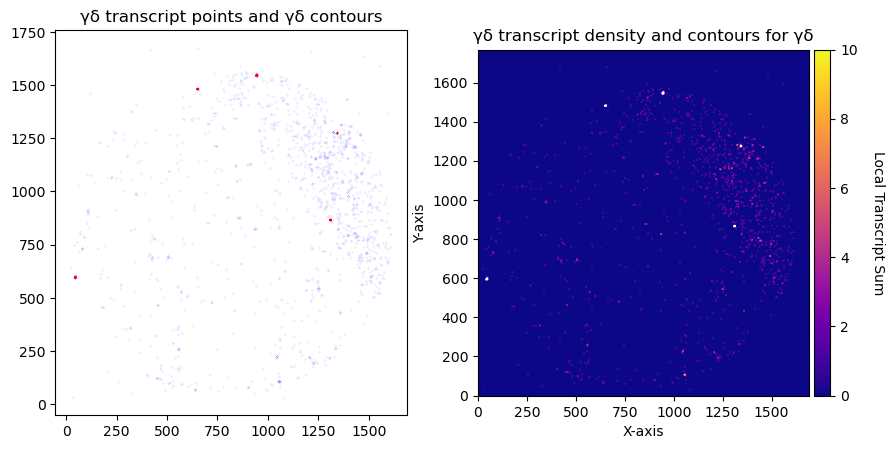

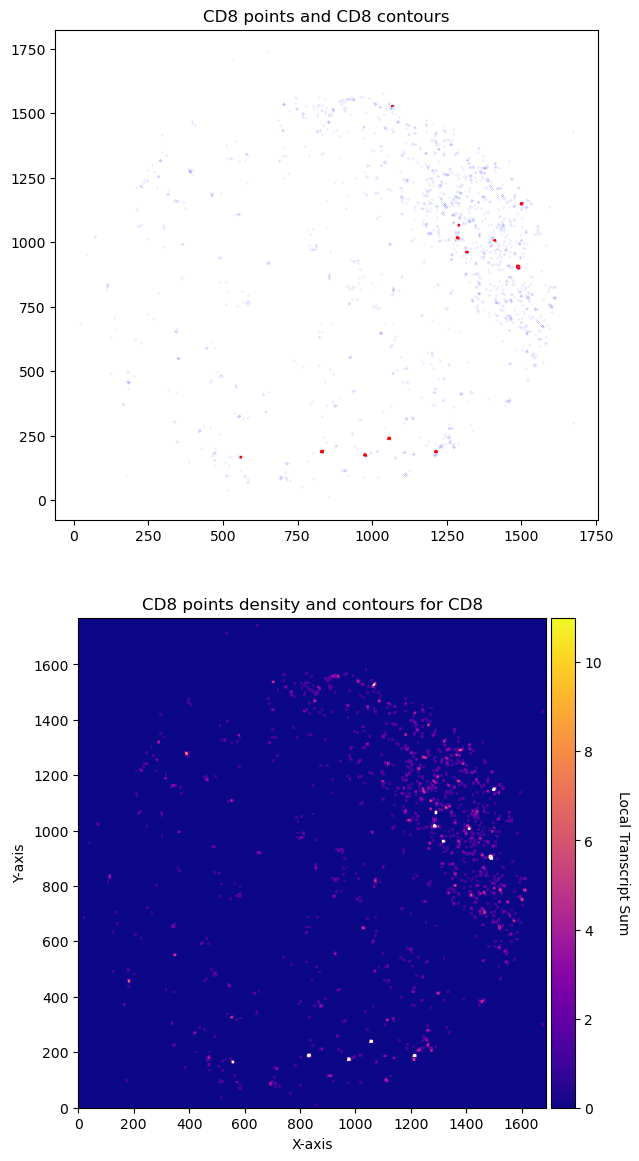

2026-02-06 00:01:31,222 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2026-02-06 00:01:31,222 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.
2026-02-06 00:01:31,223 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.


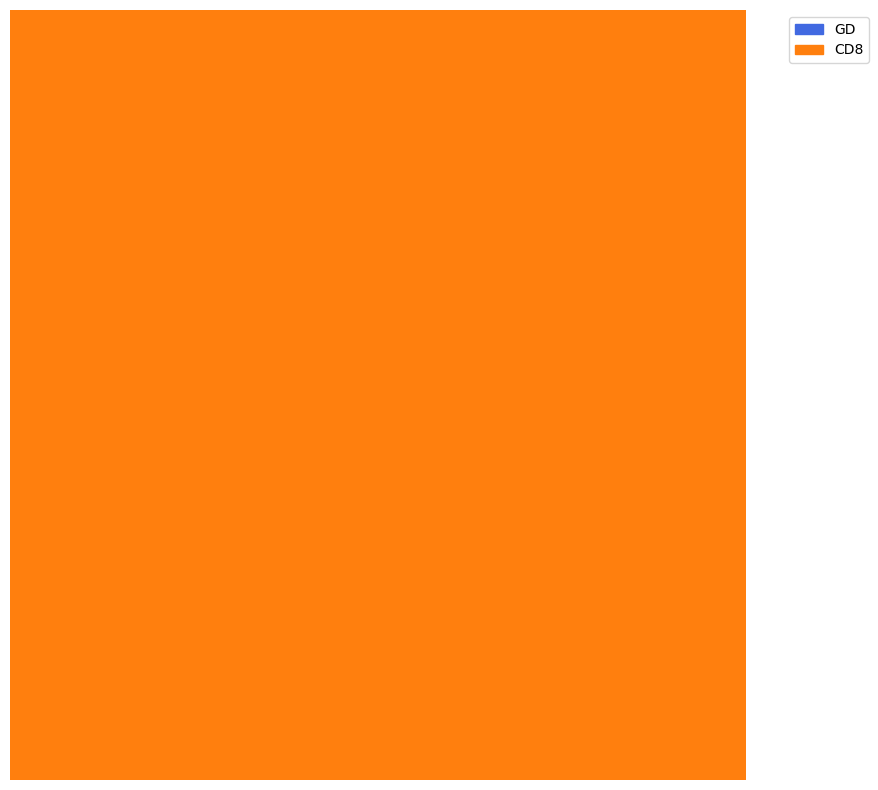

 Completed ROI002

Processing ROI003...


2026-02-06 00:01:37,657 - contour_logger - INFO - Initialized GetContour
2026-02-06 00:01:37,729 - contour_logger - INFO - get_conv_sum took 0.0710 seconds
2026-02-06 00:01:37,770 - contour_logger - INFO - Number of contours after filtering no counts: 32
2026-02-06 00:01:37,770 - contour_logger - INFO - contours_from_sum took 0.0414 seconds
2026-02-06 00:01:37,859 - contour_logger - INFO - Excluding contour 0. gd count 3.00 ≤ ab count 3.00
2026-02-06 00:01:37,879 - contour_logger - INFO - Excluding contour 2. gd count 1.00 ≤ ab count 6.00
2026-02-06 00:01:37,929 - contour_logger - INFO - Excluding contour 7. gd count 2.00 ≤ ab count 6.00
2026-02-06 00:01:37,969 - contour_logger - INFO - Excluding contour 11. gd count 3.00 ≤ ab count 4.00
2026-02-06 00:01:38,088 - contour_logger - INFO - Excluding contour 23. gd count 6.00 ≤ ab count 6.00
2026-02-06 00:01:38,118 - contour_logger - INFO - Excluding contour 26. gd count 2.00 ≤ ab count 3.00
2026-02-06 00:01:38,158 - contour_logger - INFO 

total contours found  13


2026-02-06 00:01:39,424 - contour_logger - INFO - Number of contours remaining: 164
2026-02-06 00:01:39,440 - contour_logger - INFO - Excluding contour 2. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,460 - contour_logger - INFO - Excluding contour 6. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,499 - contour_logger - INFO - Excluding contour 14. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,510 - contour_logger - INFO - Excluding contour 16. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,683 - contour_logger - INFO - Excluding contour 52. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,698 - contour_logger - INFO - Excluding contour 55. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,742 - contour_logger - INFO - Excluding contour 64. Gene TRAC count  0.0 is below threshold 1
2026-02-06 00:01:39,748 - contour_logger - INFO - Excluding contour 65. Gene TRAC count  0.0 is below threshold 1
2026-0

total contours found  111


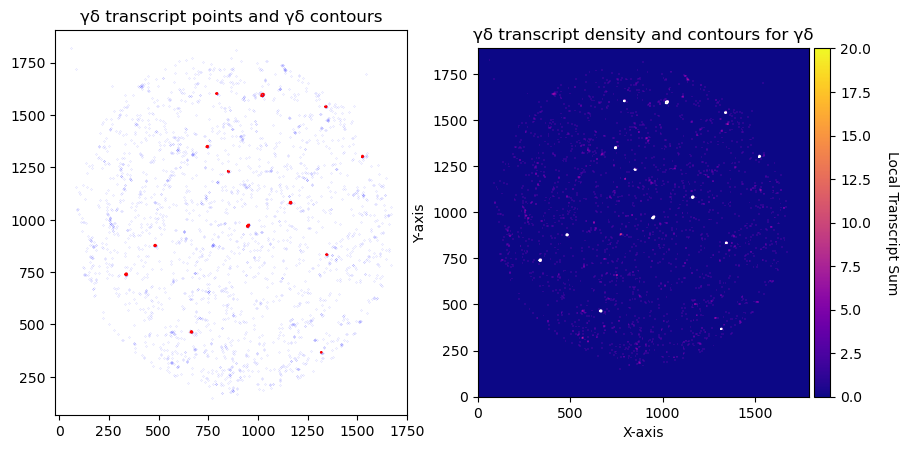

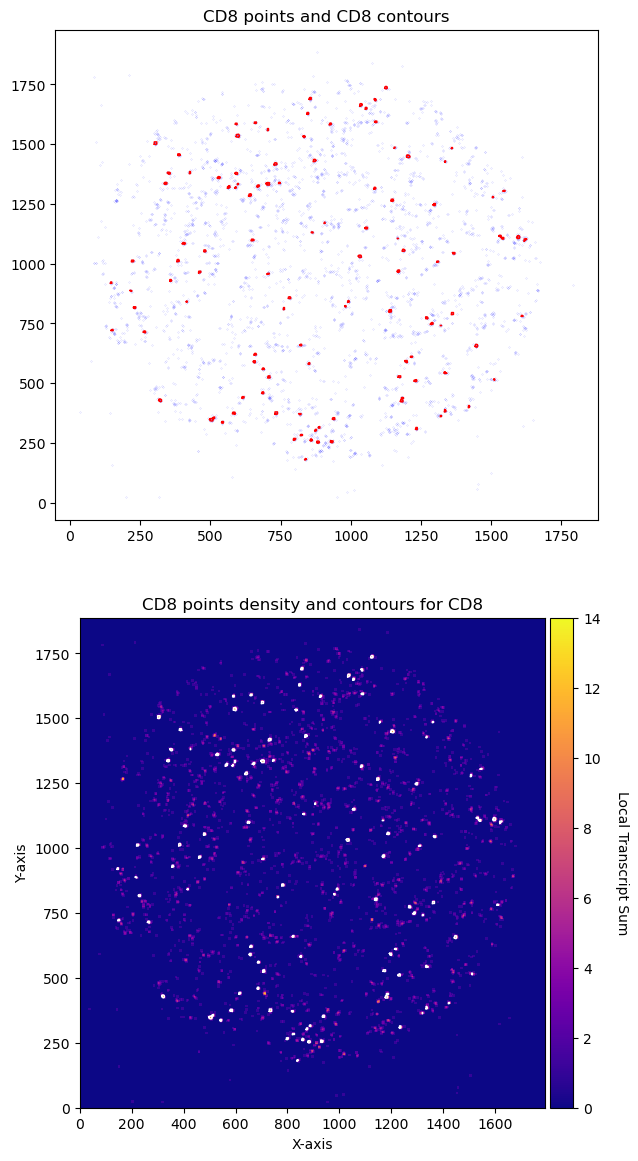

2026-02-06 00:01:44,087 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2026-02-06 00:01:44,088 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.
2026-02-06 00:01:44,088 - gridgene.get_masks.GetMasks - INFO - Mask for objects created.


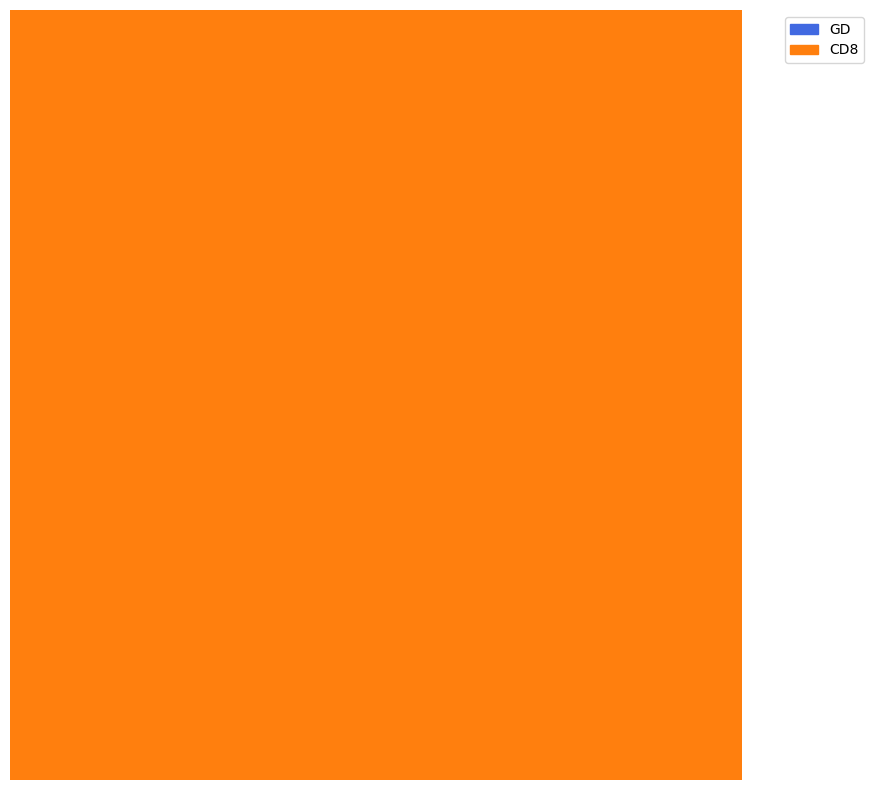

 Completed ROI003


In [36]:
target_gd = ['TRGC1', 'TRGC2', 'TRDC']
target_ab = ['TRBC1', 'TRBC2','TRAC']

target_cd8 = ['CD8A','CD8B', 'TRBC1', 'TRBC2', 'TRAC']
target_cd4 = ['CD4']

density_th_gd = 5
min_area_th_gd = 5  # 40
kernel_size_gd = 10 #90 

density_th_cd8 = 5
min_area_th_cd8 = 5
kernel_size_cd8 = 10 # 40

def gridgene_pipeline(file_csv, 
                     plot=False):
    """
    """   
    # Load and prepare data   --- only this part is different from CosMx join both 
    df_total = pd.read_csv(file_csv)
    df_total = df_total[['x_location', 'y_location', 'feature_name']]
    df_total = df_total.rename(columns={'feature_name': 'target'})
    df_total = df_total[~df_total['target'].str.contains('System|egative')]
    df_total['X'] = df_total['x_location'] - min(df_total['x_location'])
    df_total['Y'] = df_total['y_location'] - min(df_total['y_location'])
    
    n_genes = len(df_total['target'].unique())
    height = int(max(df_total['X'])) + 1
    width = int(max(df_total['Y'])) + 1
    
    target_dict_total = {target: index for index, target in enumerate(df_total['target'].unique())}
    
    # Create array
    array_total = ga.transform_df_to_array(
        df=df_total, 
        target_dict=target_dict_total, 
        array_shape=(height, width, len(target_dict_total))
    ).astype(np.int8)
           
    # creating subsets 
    df_subset_gd, array_subset_gd, target_indices_subset_gd = ga.get_subset_arrays(df_total, array_total,
                                                                                       target_dict_total,
                                                                                       target_list=target_gd,
                                                                               target_col='target')

    df_subset_ab, array_subset_ab, target_indices_subset_ab = ga.get_subset_arrays(df_total, array_total,
                                                                                           target_dict_total,
                                                                                           target_list=target_ab,
                                                                                           target_col='target')


    df_subset_g, array_subset_g, target_indices_subset_g = ga.get_subset_arrays(df_total, array_total,
                                                                                           target_dict_total,
                                                                                           target_list=['TRGC1', 'TRGC2'],
                                                                                           target_col='target')

    df_subset_d, array_subset_d, target_indices_subset_d = ga.get_subset_arrays(df_total, array_total,
                                                                                           target_dict_total,
                                                                                           target_list=['TRDC'],
                                                                                           target_col='target')


    df_subset_TRAC_gene, array_subset_TRAC_gene, target_indices_subset_TRAC_gene = ga.get_subset_arrays(df_total, 
                                                                                                     array_total,
                                                                                          target_dict_total,
                                                                                          target_list= ['TRAC'],
                                                                                          target_col='target')

    df_subset_TRBC_gene, array_subset_TRBC_gene, target_indices_subset_TRBC_gene = ga.get_subset_arrays(df_total, 
                                                                                                     array_total,
                                                                                          target_dict_total,
                                                                                          target_list= ['TRBC1', 'TRBC2'],
                                                                                          target_col='target')


    df_subset_cd8_gene, array_subset_cd8_gene, target_indices_subset_cd8_gene = ga.get_subset_arrays(df_total, 
                                                                                                     array_total,
                                                                                          target_dict_total,
                                                                                       target_list= ['CD8A', 'CD8B'],
                                                                                          target_col='target')

    df_subset_cd4_gene, array_subset_cd4_gene, target_indices_subset_cd4_gene = ga.get_subset_arrays(df_total, 
                                                                                                     array_total,
                                                                                                      target_dict_total,
                                                                                                     target_list= ['CD4'],
                                                                                target_col='target')

    ### FOR GD 
    CGD = contours.ConvolutionContours(array_subset_gd, contour_name='GD', logger=logger)
    CGD.get_conv_sum(kernel_size=kernel_size_gd, kernel_shape='square')  #
    CGD.contours_from_sum(density_threshold=density_th_gd,
                          min_area_threshold=min_area_th_gd, directionality='higher')

    ### Filtering 
    CGD.filter_contours_by_gene_comparison(gene_array1 = array_subset_gd, gene_array2 = array_subset_ab,
                                           gene_name1 = "gd", gene_name2 = "ab") # gene 1 > gene2 --> valid contour 
    # G>0 D>0
    CGD.filter_contours_by_gene_threshold(gene_array = array_subset_d.squeeze(), threshold = 1, gene_name = 'TRDC')# >= 1
    CGD.filter_contours_by_gene_threshold(gene_array = np.sum(array_subset_g, axis=-1), threshold = 1, gene_name = 'TRGC1_2')# >= 1
    print('total contours found ',len(CGD.contours))
    
    
     ### FOR CD8
    CCD8 = contours.ConvolutionContours(array_subset_cd8_gene, contour_name='CD8', logger=logger)
    CCD8.get_conv_sum(kernel_size=kernel_size_cd8, kernel_shape='square')  

    CCD8.contours_from_sum(density_threshold=density_th_cd8,
                          min_area_threshold=min_area_th_cd8, directionality='higher')

    CCD8.filter_contours_by_gene_threshold(gene_array = np.sum(array_subset_cd8_gene, axis=-1).squeeze(), threshold = 1, gene_name = 'CD8')# >= 1
    CCD8.filter_contours_by_gene_threshold(gene_array = array_subset_TRAC_gene.squeeze(), threshold = 1, gene_name = 'TRAC')# >= 1
    CCD8.filter_contours_by_gene_threshold(gene_array = np.sum(array_subset_TRBC_gene, axis=-1), threshold = 1, gene_name = 'TRBC1_2')# >= 1

    # gene_counts_ab > gene_counts_gd
    CCD8.filter_contours_by_gene_comparison(gene_array1 = array_subset_ab, gene_array2 = array_subset_gd,
                                           gene_name1 = "ab", gene_name2 = "gd") # gene 1 > gene2 --> valid contour 


    # CD8 > gene counts cd4 
    CCD8.filter_contours_by_gene_comparison(gene_array1 = array_subset_cd8_gene, gene_array2 = array_subset_cd4_gene,
                                           gene_name1 = "CD8", gene_name2 = "CD4") # gene 1 > gene2 --> valid contour
    print('total contours found ', len(CCD8.contours))

# 'contours', 'contours_filtered_area', 'contours_from_sum', 'filter_contours_area', 'filter_contours_by_gene_comparison', 'filter_contours_by_gene_threshold', 'filter_contours_no_counts'


    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    CGD.plot_contours_scatter(path=None, show=False, s=0.05, alpha=0.5, linewidth=1,
                                  c_points='blue', c_contours='red', ax=axs[0])
    axs[0].set_title('γδ transcript points and γδ contours')

    CGD.plot_conv_sum(cmap='plasma', c_countour='white', path=None, ax=axs[1])
    axs[1].set_title('γδ transcript density and contours for γδ')

    plt.show()
    
    
    fig, axs = plt.subplots(2, 1, figsize=(7, 14))

    CCD8.plot_contours_scatter(path=None, show=False, s=0.05, alpha=0.5, linewidth=1,
                                  c_points='blue', c_contours='red', ax=axs[0])
    axs[0].set_title('CD8 points and CD8 contours')

    CCD8.plot_conv_sum(cmap='plasma', c_countour='white', path=None, ax=axs[1])
    axs[1].set_title('CD8 points density and contours for CD8')

    plt.show()

    
    GM = get_masks.GetMasks(image_shape=(height, width))
    SA = get_masks.SingleClassObjectAnalysis(GM,contours_object=CGD.contours)
    mask_gd = SA.get_mask_objects(exclude_masks=None)  # Not excluding any tum or empty 
    
    SA = get_masks.SingleClassObjectAnalysis(GM,contours_object=CCD8.contours)
    mask_cd8 = SA.get_mask_objects(exclude_masks=None)  # Not excluding any tum or empty 

    
    GM.plot_masks(
        masks=[mask_gd, mask_cd8], 
        mask_names=['GD', 'CD8'],
        background_color=(1, 1, 1), 
        mask_colors={'GD': (65, 105, 225), 'Cd8': (165, 5, 125)},
        path=None, show=True,
    )


    basename = os.path.basename(file_csv)
    fov_match = re.search(r'FOV\d{3}', basename)
    fov = fov_match.group(0) if fov_match else basename.split('_')[0]

    return {
        'gd': mask_gd,
        'cd8': mask_cd8,
        'height': height,
        'width': width,
        'filename': file_csv
    }




############# RUN GRIDGENE ###################
xenium_results = {}
for fov_name, paths in roi_data.items():
    print(f"\nProcessing {fov_name}...")
    
    result = gridgene_pipeline(
        paths['xenium_path'],
        plot=True
    )

    result['fov'] = fov_name
    
    xenium_results[fov_name] = result
    print(f" Completed {fov_name}")


## 3. Compare gridgene with IMC masks

## 4. Retrieve cell segmentation
## 5. Compare Gridgene with cell phenotyping
Adapt all this code for cell segmentation retrieval. Maybe it could be the same code for everything and all the jupyter notebooks. Not sure if we are going to be able to map Xenium to the IMC directly. Cell segmentation/phenotyping with baysor? this part will not work for GD xb 

In [ ]:

def load_baysor_polygons(fov_folder):
    """Load cell polygons from Baysor JSON"""
    json_path = Path(fov_folder) / "segmentation_polygons.json"
    
    if not json_path.exists():
        raise FileNotFoundError(f"Polygons file not found: {json_path}")
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    polygons = {}
    skipped = 0
    
    for geom in data['geometries']:
        cell_id = geom['cell']
        coords = geom['coordinates'][0]
        
        if len(coords) < 4:
            skipped += 1
            continue
        
        try:
            poly = Polygon(coords)
            # DON'T check is_valid - just accept it
            polygons[cell_id] = poly
        except Exception as e:
            # If there's an actual error, print first few
            if skipped < 3:
                print(f"\n  Error with cell {cell_id}: {e}")
            skipped += 1
    
    if skipped > 0 and len(polygons) == 0:
        print(f"  ({skipped} polygons skipped, 0 valid) - CHECK DATA!", end=" ")
    elif skipped > 0:
        print(f"  ({skipped} polygons skipped)", end=" ")
    
    return polygons

print("✓ Updated load_baysor_polygons function")

def create_cell_type_masks(polygons, phenotype_df, fov, image_shape):
    """Create separate masks for each cell type"""
    fov_cells = phenotype_df.copy()
    masks = {
        'tumor': np.zeros(image_shape, dtype=np.uint8),
        'stroma': np.zeros(image_shape, dtype=np.uint8),
        'immune': np.zeros(image_shape, dtype=np.uint8)
    }
    
    for cell_id, polygon in polygons.items():
        cell_data = fov_cells[fov_cells['cellID'] == cell_id]
        if len(cell_data) == 0:
            continue
        
        compartment = cell_data['compartment'].iloc[0]
        if pd.isna(compartment) or compartment not in masks:
            continue
        
        coords = np.array(polygon.exterior.coords, dtype=np.int32)
        cv2.fillPoly(masks[compartment], [coords], 1)
    
    return masks

In [ ]:
import numpy as np
from PIL import Image, ImageDraw
def transform_mask_to_match_coordinates(mask, flip=True):
    """
    Apply transformations to align masks with coordinate system.
    Only rotate 90 degrees clockwise.
    """
    if flip:
        mask = np.rot90(mask, -1)  # Rotate 90 degrees clockwise
    return mask

def create_cell_mask_from_polygon(polygon, image_shape, min_x=0, min_y=0):
    """
    Create a binary mask from polygon with coordinate shifting.
    """
    # Extract coordinates if it's a Shapely Polygon
    if hasattr(polygon, 'exterior'):
        polygon_coords = list(polygon.exterior.coords)
    else:
        polygon_coords = polygon
    
    # Shift coordinates
    shifted_coords = [(round(x - min_x), round(y - min_y)) for x, y in polygon_coords] 

    # Create mask
    img = Image.new('L', (image_shape[1], image_shape[0]), 0)
    ImageDraw.Draw(img).polygon(shifted_coords, outline=1, fill=1)
    return np.array(img, dtype=bool)

# ============================================================================
# STEP 1: Process all FOVs and create masks
# ============================================================================
cell_results = {}
for fov_name, paths in roi_data.items():
    print(f"{fov_name}...", end=" ")
    adata_selection_ = adata_selection[adata_selection.obs['Selection'] == paths['selection_name']]
    
    if paths['baysor_json'] is None:
        print("✗ No Baysor data")
        cell_results[fov_name] = {'success': False}
        continue
    
    try:
        selection_num = paths['selection_name'].replace('Selection', '').strip()
        coords = coordinates_all[coordinates_all['Selection'] == f'Selection {selection_num}']
        min_x = coords['X'].min()
        min_y = coords['Y'].min()
        
        # Load polygons
        polygons = load_baysor_polygons(paths['baysor_folder'])
        
        if len(polygons) == 0:
            print("✗ No valid polygons")
            cell_results[fov_name] = {'success': False}
            continue
        
        # Get image shape and transform GRIDGENE masks
        image_shape = aligned_results[fov_name]['gridgene']['tumor'].shape
        
        # Transform GRIDGENE masks to match coordinate system
        transformed_masks = {}
        for mask_name in ['tumor', 'stroma', 'immune', 'other']:
            if mask_name in aligned_results[fov_name]['gridgene']:
                transformed_masks[mask_name] = transform_mask_to_match_coordinates(
                    aligned_results[fov_name]['gridgene'][mask_name],
                    flip=True
                )
        
        # Initialize cell type masks (aggregated by compartment)
        cell_type_masks = {
            'tumor': np.zeros(image_shape, dtype=bool),
            'stroma': np.zeros(image_shape, dtype=bool),
            'immune': np.zeros(image_shape, dtype=bool),
            'other': np.zeros(image_shape, dtype=bool)
        }
        
        # Create cell masks and compute overlaps
        cell_overlaps = {}
        for cell_id, polygon in polygons.items():
            # Create cell mask with coordinate shifting
            cell_mask = create_cell_mask_from_polygon(
                polygon,
                image_shape,
                min_x=min_x,
                min_y=min_y
            )
            
            # Get cell type from adata and add to cell type mask
            cell_info = adata_selection_.obs[adata_selection_.obs['cellID'] == cell_id]
            if len(cell_info) > 0:
                compartment = cell_info['compartment'].values[0]
                # Add this cell's mask to the appropriate compartment mask
                if compartment in cell_type_masks:
                    cell_type_masks[compartment] |= cell_mask
            
            # Compute overlap with each GRIDGENE mask
            cell_overlaps[cell_id] = {}
            total_cell_pixels = np.count_nonzero(cell_mask)
            
            for mask_name, mask in transformed_masks.items():
                overlap = np.count_nonzero(mask[cell_mask])
                cell_overlaps[cell_id][mask_name] = overlap
                # Store percentage too
                cell_overlaps[cell_id][f'{mask_name}_pct'] = (
                    100 * overlap / total_cell_pixels if total_cell_pixels > 0 else 0
                )
        
        cell_results[fov_name] = {
            'success': True,
            'polygons': polygons,
            'overlaps': cell_overlaps,
            'masks': cell_type_masks,  # Cell type masks for visualization
            'transformed_masks': transformed_masks,
            'n_cells': len(polygons)
        }
        
        print(f"✓ {len(polygons)} cells")
        
    except Exception as e:
        import traceback
        print(f"✗ {e}")
        traceback.print_exc()
        cell_results[fov_name] = {'success': False, 'error': str(e)}

print("=" * 80)
n_success = sum(1 for r in cell_results.values() if r.get('success', False))
print(f"Successfully processed {n_success}/{len(cell_results)} FOVs")

# ============================================================================
# STEP 2: Analyze cell distributions
# ============================================================================
def analyze_cell_distribution(fov_name):
    """Analyze which cell types fall into which GRIDGENE compartments"""
    
    if not cell_results[fov_name].get('success', False):
        return None
    
    # Get TRANSFORMED GRIDGENE masks (already flipped/rotated)
    gg_tumor = cell_results[fov_name]['transformed_masks']['tumor']
    gg_stroma = cell_results[fov_name]['transformed_masks']['stroma']
    
    # Get cell type masks (already in correct coordinate system)
    cell_tumor = cell_results[fov_name]['masks']['tumor']
    cell_stroma = cell_results[fov_name]['masks']['stroma']
    cell_immune = cell_results[fov_name]['masks']['immune']
    
    analysis = {
        'fov': fov_name,
        # Where do epithelial cells go?
        'epithelial_total': cell_tumor.sum(),
        'epithelial_in_gg_tumor': (cell_tumor & gg_tumor).sum(),
        'epithelial_in_gg_stroma': (cell_tumor & gg_stroma).sum(),
        
        # Where do stroma cells go?
        'stroma_total': cell_stroma.sum(),
        'stroma_in_gg_tumor': (cell_stroma & gg_tumor).sum(),
        'stroma_in_gg_stroma': (cell_stroma & gg_stroma).sum(),
        
        # Where do immune cells go?
        'immune_total': cell_immune.sum(),
        'immune_in_gg_tumor': (cell_immune & gg_tumor).sum(),
        'immune_in_gg_stroma': (cell_immune & gg_stroma).sum(),
    }
    
    # Calculate percentages
    if analysis['epithelial_total'] > 0:
        analysis['epithelial_in_tumor_pct'] = (analysis['epithelial_in_gg_tumor'] / analysis['epithelial_total']) * 100
        analysis['epithelial_in_stroma_pct'] = (analysis['epithelial_in_gg_stroma'] / analysis['epithelial_total']) * 100
    else:
        analysis['epithelial_in_tumor_pct'] = 0
        analysis['epithelial_in_stroma_pct'] = 0
    
    if analysis['stroma_total'] > 0:
        analysis['stroma_in_tumor_pct'] = (analysis['stroma_in_gg_tumor'] / analysis['stroma_total']) * 100
        analysis['stroma_in_stroma_pct'] = (analysis['stroma_in_gg_stroma'] / analysis['stroma_total']) * 100
    else:
        analysis['stroma_in_tumor_pct'] = 0
        analysis['stroma_in_stroma_pct'] = 0
    
    if analysis['immune_total'] > 0:
        analysis['immune_in_tumor_pct'] = (analysis['immune_in_gg_tumor'] / analysis['immune_total']) * 100
        analysis['immune_in_stroma_pct'] = (analysis['immune_in_gg_stroma'] / analysis['immune_total']) * 100
    else:
        analysis['immune_in_tumor_pct'] = 0
        analysis['immune_in_stroma_pct'] = 0
    
    return analysis

# Analyze all FOVs
cell_distributions = {}
for fov_name in roi_data.keys():
    analysis = analyze_cell_distribution(fov_name)
    if analysis:
        cell_distributions[fov_name] = analysis

print(f"✓ Analyzed cell distributions for {len(cell_distributions)} FOVs")

# Create dataframe
records = []
for fov_name, analysis in cell_distributions.items():
    records.append({
        'FOV': fov_name,
        'Cell Type': 'Epithelial',
        'In GG Tumor': analysis['epithelial_in_tumor_pct'],
        'In GG Stroma': analysis['epithelial_in_stroma_pct']
    })
    records.append({
        'FOV': fov_name,
        'Cell Type': 'Stroma',
        'In GG Tumor': analysis['stroma_in_tumor_pct'],
        'In GG Stroma': analysis['stroma_in_stroma_pct']
    })
    records.append({
        'FOV': fov_name,
        'Cell Type': 'Immune',
        'In GG Tumor': analysis['immune_in_tumor_pct'],
        'In GG Stroma': analysis['immune_in_stroma_pct']
    })

df_dist = pd.DataFrame(records)
print(df_dist)

In [ ]:
def visualize_cell_assignments_final(fov_name):
    """
    3-column visualization with BLACK polygon outlines visible on all colors
    """
    
    if not cell_results[fov_name].get('success', False):
        print(f"{fov_name}: No cell segmentation data")
        return
    
    # Get data
    cell_masks = cell_results[fov_name]['masks']
    gg_masks = cell_results[fov_name]['transformed_masks']  # Use transformed masks
    if_image = imc_results[fov_name]['image']
    polygons = cell_results[fov_name]['polygons']
    
    # Get phenotype data for this FOV - FIX: get .obs
    selection_name = roi_data[fov_name]['selection_name']
    fov_cells = adata_selection[adata_selection.obs['Selection'] == selection_name].obs

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # ===== Column 1: Cells colored by PHENOTYPE =====
    # White background
    cell_phenotype = np.ones((*cell_masks['tumor'].shape, 3), dtype=np.float32)
    
    # Fill polygons with colors (order matters - do NOT overlap)
    cell_phenotype[cell_masks['tumor']] = [1, 0, 0]      # Red: Epithelial (tumor)
    cell_phenotype[cell_masks['stroma']] = [0, 0, 1]     # Blue: Stroma
    cell_phenotype[cell_masks['immune']] = [0, 1, 0]     # Green: Immune
    
    # Convert to uint8 for cv2
    cell_phenotype_uint8 = (cell_phenotype * 255).astype(np.uint8)
    
    # Draw BLACK polygon outlines (will show on all colors)
    for cell_id, polygon in polygons.items():
        coords = np.array(polygon.exterior.coords, dtype=np.int32)
        cv2.polylines(cell_phenotype_uint8, [coords], isClosed=True, color=(0, 0, 0), thickness=2)
    
    axes[0].imshow(cell_phenotype_uint8)
    axes[0].set_title(f'{fov_name}\nBaysor Cells by Phenotype\n(Red=Epithelial, Blue=Stroma, Green=Immune)', 
                     fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # ===== Column 2: Cells colored by GRIDGENE MASK they fall into =====
    # White background
    all_cells = (cell_masks['tumor'] | cell_masks['stroma'] | cell_masks['immune']).astype(bool)
    
    cells_in_gg_tumor = all_cells & gg_masks['tumor'].astype(bool)
    cells_in_gg_stroma = all_cells & gg_masks['stroma'].astype(bool)
    cells_in_both = cells_in_gg_tumor & cells_in_gg_stroma
    cells_only_tumor = cells_in_gg_tumor & ~cells_in_gg_stroma
    cells_only_stroma = cells_in_gg_stroma & ~cells_in_gg_tumor
    
    cell_gg_assignment = np.ones((*cell_masks['tumor'].shape, 3), dtype=np.float32)
    cell_gg_assignment[cells_only_tumor] = [1, 0, 0]       # Red: In GRIDGENE Tumor only
    cell_gg_assignment[cells_only_stroma] = [0, 1, 0]      # Green: In GRIDGENE Stroma only
    cell_gg_assignment[cells_in_both] = [1, 1, 0]          # Yellow: In both
    
    # Convert to uint8 for cv2
    cell_gg_assignment_uint8 = (cell_gg_assignment * 255).astype(np.uint8)
    
    # Draw BLACK polygon outlines (will show on all colors)
    for cell_id, polygon in polygons.items():
        coords = np.array(polygon.exterior.coords, dtype=np.int32)
        cv2.polylines(cell_gg_assignment_uint8, [coords], isClosed=True, color=(0, 0, 0), thickness=2)
    
    axes[1].imshow(cell_gg_assignment_uint8)
    axes[1].set_title('Baysor Cells by GRIDGENE Assignment\n(Red=In Tumor, Green=In Stroma, Yellow=Both)', 
                     fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    # ===== Column 3: IF Reference =====
    axes[2].imshow(if_image)
    axes[2].set_title('IF Reference Image\n(Red=Epithelial, Green=Stroma, Blue=Nuclei)', 
                     fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print complete statistics for ALL cell types
    if fov_name in cell_distributions:
        analysis = cell_distributions[fov_name]
        
        # Count actual cells by compartment
        epithelial_cells = fov_cells[fov_cells['compartment'] == 'tumor']
        stroma_cells = fov_cells[fov_cells['compartment'] == 'stroma']
        immune_cells = fov_cells[fov_cells['compartment'] == 'immune']
        
        # Break down stroma by cell type if available
        if 'major_cluster' in fov_cells.columns:
            fibroblasts = fov_cells[fov_cells['major_cluster'] == 'Fibroblasts']
            endothelial = fov_cells[fov_cells['major_cluster'] == 'Endothelial cells']
        else:
            fibroblasts = pd.DataFrame()
            endothelial = pd.DataFrame()
        
        print(f"\n{fov_name} - Cell Distribution Summary:")
        print("=" * 80)
        
        print(f"\nEPITHELIAL CELLS:")
        print(f"  Total: {len(epithelial_cells)} cells ({analysis['epithelial_total']:,} pixels)")
        print(f"  → GRIDGENE Tumor:  {analysis['epithelial_in_tumor_pct']:5.1f}% ({analysis['epithelial_in_gg_tumor']:,} pixels) ✓ CORRECT")
        print(f"  → GRIDGENE Stroma: {analysis['epithelial_in_stroma_pct']:5.1f}% ({analysis['epithelial_in_gg_stroma']:,} pixels) ✗ ERROR")
        
        print(f"\nSTROMA CELLS (Fibroblasts + Endothelial):")
        print(f"  Total: {len(stroma_cells)} cells ({analysis['stroma_total']:,} pixels)")
        if len(fibroblasts) > 0 or len(endothelial) > 0:
            print(f"    - Fibroblasts: {len(fibroblasts)} cells")
            print(f"    - Endothelial: {len(endothelial)} cells")
        print(f"  → GRIDGENE Tumor:  {analysis['stroma_in_tumor_pct']:5.1f}% ({analysis['stroma_in_gg_tumor']:,} pixels) ✗ ERROR")
        print(f"  → GRIDGENE Stroma: {analysis['stroma_in_stroma_pct']:5.1f}% ({analysis['stroma_in_gg_stroma']:,} pixels) ✓ CORRECT")
        
        print(f"\nIMMUNE CELLS (Lymphocytes, Myeloid, Plasma):")
        print(f"  Total: {len(immune_cells)} cells ({analysis['immune_total']:,} pixels)")
        print(f"  → GRIDGENE Tumor:  {analysis['immune_in_tumor_pct']:5.1f}% ({analysis['immune_in_gg_tumor']:,} pixels)")
        print(f"  → GRIDGENE Stroma: {analysis['immune_in_stroma_pct']:5.1f}% ({analysis['immune_in_gg_stroma']:,} pixels)")
        print(f"  Note: Immune cells can infiltrate both tumor and stroma compartments")
        print("=" * 80)

# Visualize all FOVs
print("Visualizing cell phenotype vs GRIDGENE assignment (3 columns)...\n")
print("=" * 80)
for fov_name in sorted(roi_data.keys()):
    if cell_results.get(fov_name, {}).get('success', False):
        visualize_cell_assignments_final(fov_name)
        print("\n" + "=" * 80 + "\n")

In [ ]:
# ============================================================================
# VISUALIZATION 1: Boxplots showing distribution across FOVs
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'Epithelial': '#ff6b6b', 'Stroma': '#4ecdc4', 'Immune': '#95e1d3'}

for idx, cell_type in enumerate(['Epithelial', 'Stroma', 'Immune']):
    data = df_dist[df_dist['Cell Type'] == cell_type]
    
    # Prepare data for boxplot
    boxplot_data = [data['In GG Tumor'], data['In GG Stroma']]
    
    bp = axes[idx].boxplot(boxplot_data, 
                           labels=['In GRIDGENE\nTumor', 'In GRIDGENE\nStroma'],
                           patch_artist=True,
                           widths=0.6)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor(colors[cell_type])
        patch.set_alpha(0.7)
    
    # Overlay individual FOV points
    for i, location in enumerate(['In GG Tumor', 'In GG Stroma']):
        y_data = data[location].values
        x_data = np.random.normal(i+1, 0.04, size=len(y_data))  # Add jitter
        axes[idx].scatter(x_data, y_data, alpha=0.6, s=100, 
                         edgecolors='black', linewidth=1.5, zorder=3)
        
        # Label each point with FOV name
        for x, y, fov in zip(x_data, y_data, data['FOV']):
            axes[idx].text(x, y, fov.replace('FOV', ''), 
                          fontsize=8, ha='center', va='center',
                          fontweight='bold', color='white')
    
    axes[idx].set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    
    # Custom titles based on expected behavior
    if cell_type == 'Epithelial':
        title = f'{cell_type} Cells\n(Should be in Tumor)'
    elif cell_type == 'Stroma':
        title = f'{cell_type} Cells\n(Fibroblasts + Endothelial, should be in Stroma)'
    else:
        title = f'{cell_type} Cells\n(Can infiltrate both)'
    
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].set_ylim([0, 105])
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add mean values
    mean_tumor = data['In GG Tumor'].mean()
    mean_stroma = data['In GG Stroma'].mean()
    axes[idx].text(1, 100, f'μ={mean_tumor:.1f}%', 
                  fontsize=10, ha='center', fontweight='bold', 
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[idx].text(2, 100, f'μ={mean_stroma:.1f}%', 
                  fontsize=10, ha='center', fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Cell Type Distribution Across GRIDGENE Masks (Per FOV)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Heatmap showing per-FOV accuracy
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Epithelial cells in tumor (should be high)
epithelial_data = df_dist[df_dist['Cell Type'] == 'Epithelial'].pivot(
    index='FOV', columns='Cell Type', values='In GG Tumor'
)
epithelial_data.columns = ['Epithelial → Tumor (%)']

# Heatmap 2: Stroma cells in stroma (should be high)
stroma_data = df_dist[df_dist['Cell Type'] == 'Stroma'].pivot(
    index='FOV', columns='Cell Type', values='In GG Stroma'
)
stroma_data.columns = ['Stroma → Stroma (%)']

# Plot epithelial accuracy
sns.heatmap(epithelial_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            vmin=0, vmax=100, center=70, cbar_kws={'label': 'Percentage (%)'},
            linewidths=2, linecolor='black', ax=axes[0])
axes[0].set_title('Epithelial Cell Accuracy\n(Should be in GRIDGENE Tumor)', 
                 fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('FOV', fontsize=12, fontweight='bold')

# Plot stroma accuracy
sns.heatmap(stroma_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            vmin=0, vmax=100, center=70, cbar_kws={'label': 'Percentage (%)'},
            linewidths=2, linecolor='black', ax=axes[1])
axes[1].set_title('Stroma Cell Accuracy\n(Fibroblasts + Endothelial, should be in GRIDGENE Stroma)', 
                 fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('FOV', fontsize=12, fontweight='bold')

plt.suptitle('Per-FOV Cell Type Classification Accuracy', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# PRINT DETAILED STATISTICS
# ============================================================================

print("\nDETAILED STATISTICS PER FOV:")
print("=" * 80)

for fov_name in sorted(cell_distributions.keys()):
    analysis = cell_distributions[fov_name]
    print(f"\n{fov_name}:")
    print(f"  Epithelial → GG Tumor:  {analysis['epithelial_in_tumor_pct']:5.1f}%  "
          f"(✓ correct) | → GG Stroma: {analysis['epithelial_in_stroma_pct']:5.1f}%  (✗ error)")
    print(f"  Stroma     → GG Stroma: {analysis['stroma_in_stroma_pct']:5.1f}%  "
          f"(✓ correct) | → GG Tumor:  {analysis['stroma_in_tumor_pct']:5.1f}%  (✗ error)")
    print(f"  Immune     → GG Tumor:  {analysis['immune_in_tumor_pct']:5.1f}%  "
          f"| → GG Stroma: {analysis['immune_in_stroma_pct']:5.1f}%  (both OK)")

print("\n" + "=" * 80)
print("SUMMARY STATISTICS (ACROSS ALL FOVs):")
print("=" * 80)

for cell_type in ['Epithelial', 'Stroma', 'Immune']:
    data = df_dist[df_dist['Cell Type'] == cell_type]
    print(f"\n{cell_type} cells:")
    print(f"  In GRIDGENE Tumor:  {data['In GG Tumor'].mean():.1f}% ± {data['In GG Tumor'].std():.1f}%")
    print(f"  In GRIDGENE Stroma: {data['In GG Stroma'].mean():.1f}% ± {data['In GG Stroma'].std():.1f}%")


macrophages? CD8? 
Do the same for cosmz if cell segmentation???? 

['IL17RA' 'EGR1' 'DES' 'COL4A1' 'COL11A1' 'CCR1' 'MYC' 'COL1A1' 'THBS1'
 'COL4A2' 'COL3A1' 'CCL2' 'SPARC' 'FCGR3B' 'LAMP1' 'IFITM3' 'CD58' 'FAP'
 'IGHG1' 'VWF' 'SPP1' 'TIMP2' 'THY1' 'HLA-DQA1' 'FCER1G' 'CLEC7A' 'VIM'
 'ACTA2' 'CD55' 'HLA-G' 'CXCL9' 'LUM' 'CD68' 'ADAM28' 'SATB2' 'CD1A'
 'JAML' 'BTN3A3' 'TRBC1' 'COL6A2' 'HLA-DRB1' 'C3' 'TRAC' 'SPON2' 'PLVAP'
 'SOX4' 'IDO1' 'CCL11' 'ITGB1' 'COL10A1' 'MAF' 'TNF' 'COL7A1' 'LAMP3'
 'TGFB1' 'TAGLN' 'NT5E' 'FCGR2A' 'EFNB2' 'CCR3' 'CLU' 'IGFBP7' 'CHI3L1'
 'CXCL12' 'INHBA' 'IFITM1' 'IGHG4' 'IFI30' 'TRGC2' 'IL6ST' 'IL2RA' 'CTSH'
 'CD93' 'EMP1' 'LGALS1' 'ACTG2' 'DPT' 'S100A4' 'ITGA4' 'HLA-E' 'TFPI2'
 'FLT3' 'CLEC5A' 'FCGR2B' 'IFIT1' 'KRT18' 'PDGFRA' 'CD81' 'STXBP2' 'MMP3'
 'MFAP5' 'KIT' 'MDM2' 'NRXN1' 'HES1' 'S100A12' 'CD8A' 'FCGR3A' 'TRDC'
 'CEACAM1' 'PTPRC' 'LCN2' 'FSCN1' 'IL33' 'PLA2G2A' 'FCGR1A' 'LGALS9'
 'CD83' 'C1QC' 'ICAM1' 'ANXA1' 'LILRA4' 'JUND' 'ITGA1' 'MYH11' 'ISG20'
 'CTSL' 'EPCAM' 'SOX10' 'STMN1' 'IGHM' 'WNT5B' 'CD3G' 'CD47' 'A2M' 'KRT8'
 'HLA-A' 'HLA-DRA' 'PMAIP1' 'JUN' 'PDGFB' 'SERPINF1' 'APOE' 'CSF1'
 'IL1RL1' 'TIGIT' 'WNT4' 'PTGS2' 'XCL1' 'COLEC12' 'SCARA5' 'BTN2A2'
 'AXIN2' 'TOX' 'REG3A' 'IKZF2' 'ICOSLG' 'CILP' 'CD200' 'GZMA' 'TCF7'
 'CCL8' 'CXCL16' 'MS4A7' 'S100A13' 'CCL13' 'LGALS8' 'SMAD7' 'LILRB2'
 'ITGB2' 'PKIB' 'CXCR3' 'SOX6' 'CCL22' 'GZMK' 'WDFY4' 'IGF1' 'FCGBP'
 'BTN3A1' 'TRDV2' 'TWIST1' 'CD300E' 'NTRK2' 'IL7' 'RIPOR2' 'OGN' 'CCL4'
 'C1QTNF3' 'TRBC2' 'INHBB' 'IRF8' 'C1QA' 'IL18' 'ULBP1' 'LYVE1' 'MICA'
 'VEGFC' 'FKBP5' 'FOLR2' 'GPR183' 'TNFSF13B' 'VSIR' 'PRF1' 'HRH2' 'NKG7'
 'ASF1B' 'CD14' 'VCAM1' 'RBPJ' 'CD3E' 'CSF2RA' 'CSF3' 'S100A9' 'ISG15'
 'SFRP2' 'CD163' 'CPA3' 'CDKN1A' 'KLF2' 'SIRPA' 'DCN' 'ENPP1' 'RNASE1'
 'VEGFA' 'KDR' 'CXCR4' 'SDC1' 'CLEC2D' 'MMRN1' 'AGT' 'BIRC3' 'RERGL'
 'FASLG' 'CXCR2' 'ACKR2' 'LEF1' 'AREG' 'SPI1' 'BTNL9' 'CLEC9A' 'F3' 'IL1A'
 'CLIC3' 'CAV1' 'CD22' 'ENTPD1' 'ITGA2' 'CD33' 'SHISA3' 'GATA3' 'ACKR3'
 'POU2AF1' 'RORA' 'CXCL2' 'HMGA2' 'IL6' 'CXCL3' 'HCST' 'SH2D1B' 'NEIL1'
 'KLRK1' 'HAVCR2' 'S100B' 'PTGER2' 'C1QB' 'TNFAIP6' 'CD86' 'BTN3A2' 'MPO'
 'PTPN22' 'FOSB' 'APLNR' 'NOTCH3' 'CLEC4A' 'PDGFRB' 'RORC' 'BCL6' 'LGALS3'
 'IRF4' 'ACKR1' 'CD38' 'RGCC' 'CADM1' 'RGS5' 'SELL' 'BTN2A1' 'CCN5' 'CD2'
 'OMD' 'CCR9' 'PODXL' 'IL7R' 'COL4A5' 'XCL2' 'FAS' 'LGALS2' 'ULBP2' 'CD52'
 'CD4' 'IL3RA' 'IL2' 'FCN1' 'NOSIP' 'PCLAF' 'SNAI1' 'IL15' 'ULBP3' 'SMPD3'
 'CD80' 'BTLA' 'L1CAM' 'CCR5' 'IL5' 'MS4A1' 'SOX2' 'LMO2' 'TYROBP'
 'LILRB1' 'IL10RA' 'GZMH' 'CXCL6' 'RTKN2' 'CXCL14' 'NCR1' 'NSG1' 'KLRB1'
 'HPGDS' 'EREG' 'CCR7' 'KLRD1' 'NCAM1' 'HLA-DOB' 'CCL5' 'CXCR6' 'IFNG'
 'FLT1' 'PROX1' 'BATF3' 'TK1' 'CCR4' 'KLRC1' 'CCL7' 'HEY1' 'FOXP3'
 'APOBEC3G' 'FCRL5' 'CD79A' 'CD79B' 'OLR1' 'IL4I1' 'LTB' 'KLRG1' 'IL1RN'
 'MZB1' 'IFNB1' 'FOLH1' 'TPSB2' 'CCR2' 'CCL18' 'CD160' 'CCRL2' 'MARCO'
 'CTLA4' 'CCL15' 'LAT2' 'MS4A12' 'CCR6' 'SEMA3G' 'CLEC1A' 'IL11' 'CD1D'
 'GCSAM' 'IRF7' 'PRDM16' 'IL22RA2' 'CD1E' 'TBX21' 'RGS13' 'PDK4' 'IL10'
 'CCR8' 'EOMES' 'RASGRP2' 'CXCL13' 'SELP' 'KIR2DL4' 'CD69' 'HCAR2' 'REG1B'
 'IGHG2' 'LILRA5' 'TLR10' 'ITLN1' 'FCER1A' 'IFNE' 'LGR5' 'CA9' 'BLK'
 'CSF3R' 'TNFSF11' 'GZMB' 'KLRC2' 'S100A8' 'DNASE1L3' 'CCL19' 'MICB'
 'TNFRSF13C' 'LAG3' 'CXCR5' 'ICOS' 'EBI3' 'CCL20' 'ZWINT' 'GNLY' 'IL12A'
 'CD40LG' 'BMP5' 'NCR3' 'B3GAT1' 'TRGC1' 'ASB2' 'KLRF1' 'TNFRSF17'
 'APOBEC3A' 'CLNK' 'SFTPD' 'TRDV3' 'FGFBP2' 'HMSD' 'CSF2' 'CCL21' 'REG1A'
 'CCL14' 'CD7' 'CXCL1' 'MMP1' 'TRDV1' 'CLEC10A' 'IGHE' 'RELN' 'CD247'
 'IL17A' 'LAD1' 'CD36' 'ELANE' 'CD45RO' 'TMIGD2' 'IL13' 'CA2' 'CCL16'
 'TXK' 'SOSTDC1' 'IL1B' 'MMP12' 'CD1C' 'IL4' 'FOXD3' 'XCR1' 'CDH19'
 'SPINK2' 'ADAMDEC1' 'CTSW' 'ZNF683' 'APLN' 'TNFRSF18' 'TPSAB1' 'CXCR1'
 'CD320' 'CD19' 'IL21' 'NCR2' 'CENPM' 'ITGAE' 'CCL1' 'GFRA3' 'CEACAM7'
 'MS4A2' 'ADGRG3' 'CCL17' 'TMEM88' 'CXCL5' 'PTCRA' 'FCER2' 'PDCD1' 'IGHA2'
 'NDUFA4L2' 'IGHD' 'VPREB3' 'LST1' 'CD45RA']